In [70]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [71]:
words = open('names.txt', 'r').read().splitlines()
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)



In [72]:
import random
random.seed(42)
random.shuffle(words)
block_size = 8

def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0]*block_size
        for ch in w+'.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:]+[ix]
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y
# divide data sets in to proper segments of traning data, dev/valuation data, and test data
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))
Xtr, Ytr = build_dataset(words[:n1])
Xval, Yval = build_dataset(words[n1:n2])
Xtest, Ytest = build_dataset(words[n2:])

In [73]:
class Linear:
    def __init__(self, fan_in, fan_out, bias=True):
        self.weight = torch.randn((fan_in, fan_out), generator=g) / fan_in**0.5
        self.bias = torch.zeros(fan_out) if bias else None
    def __call__(self, x):
        self.out = x@ self.weight
        if self.bias is not None:
            self.out += self.bias
        self.out.retain_grad()
        return self.out
    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])
    
class BatchNorm1d:
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps = eps
        self.momentum = momentum
        self.training = True
        #paramenters (trained with backprop)
        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        #buffers (trained with running momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var = torch.ones(dim)

    def __call__(self, x):
        #calc forward pass
        if self.training:
            xmean = x.mean(0, keepdim=True)
            xvar = x.var(0, keepdim=True, unbiased=True)
        else:
            xmean = self.running_mean
            xvar = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps)#normalize and make sure we have value under sqrt
        self.out = self.gamma * xhat + self.beta
        #update running stats
        if self.training:
            with torch.no_grad():
                self.running_mean = (1-self.momentum)*self.running_mean + self.momentum*xmean
                self.running_var = (1-self.momentum)*self.running_var + self.momentum*xvar
        return self.out
    def parameters(self):
        return [self.gamma, self.beta]
    
class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        self.out.retain_grad()
        return self.out
    def parameters(self):
        return []

n_embd = 10
n_hidden = 100
g = torch.Generator().manual_seed(2147483647)

C = torch.randn((vocab_size, n_embd), generator = g)

layers = [
        Linear(n_embd*block_size, n_hidden), Tanh(),
        Linear(n_hidden, n_hidden), Tanh(),
        Linear(n_hidden, n_hidden), Tanh(),
        Linear(n_hidden, n_hidden), Tanh(),
        Linear(n_hidden, n_hidden), Tanh(),
        Linear(n_hidden, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1
    for layer in layers[:-1]:  # Don't scale the final batch norm
        if isinstance(layer, Linear):
            layer.weight *= 5/3

parameters = [C] + [p for layer in layers for p in layer.parameters()]
for p in parameters:
    p.requires_grad = True
print(sum(p.nelement() for p in parameters))

51497


In [74]:
max_steps = 200000
batch_size = 32
lossi = []
ud = []

for i in range(max_steps):
    xi = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    xb, yb = Xtr[xi], Ytr[xi]
    emb = C[xb]
    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, yb)
    for p in parameters:
        p.grad = None
    
    lr = 0.1 if i < 100000 else 0.01
    loss.backward()
    for p in parameters:
        p.data += -lr * p.grad

    if i%10000 == 0:
        print(f'{i:7d}/{max_steps}: {loss.item():.4f}')
    lossi.append(loss.item())
    with torch.no_grad():
        ud.append([(lr*p.grad.std()/p.data.std()).log10().item() for p in parameters])
    if i>=1000:
        break


      0/200000: 3.2960


layer 1 (      Tanh): mean -0.06, std 0.76, saturated: 21.47%
layer 3 (      Tanh): mean +0.02, std 0.73, saturated: 14.69%
layer 5 (      Tanh): mean -0.01, std 0.73, saturated: 14.66%
layer 7 (      Tanh): mean +0.01, std 0.74, saturated: 14.72%
layer 9 (      Tanh): mean +0.00, std 0.71, saturated: 10.94%


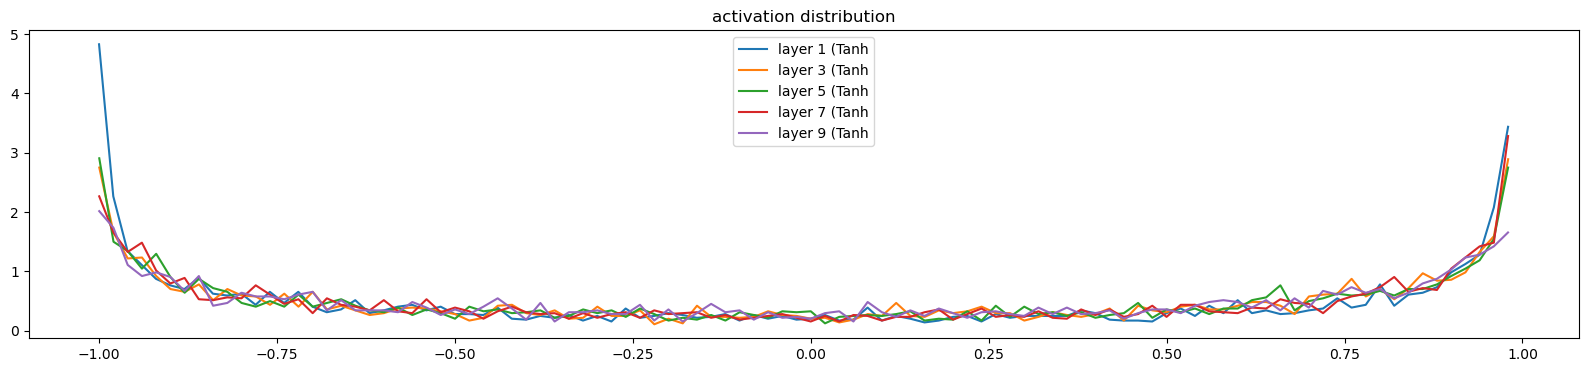

In [75]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out
    print('layer %d (%10s): mean %+.2f, std %.2f, saturated: %.2f%%' % (i, layer.__class__.__name__, t.mean(), t.std(), (t.abs() > 0.97).float().mean()*100))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('activation distribution')


plt.show()

layer 1 (      Tanh): mean -0.000061, std 2.470812e-03
layer 3 (      Tanh): mean +0.000020, std 2.372224e-03
layer 5 (      Tanh): mean +0.000036, std 2.310202e-03
layer 7 (      Tanh): mean -0.000005, std 2.181128e-03
layer 9 (      Tanh): mean -0.000046, std 1.872947e-03


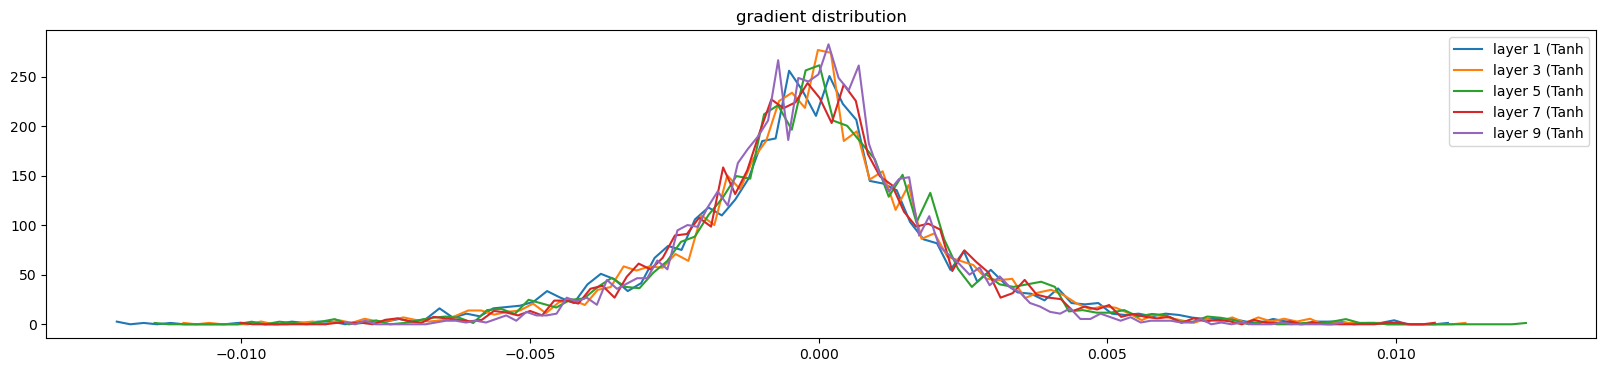

In [76]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i, layer in enumerate(layers[:-1]): # note: exclude the output layer
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} ({layer.__class__.__name__}')
plt.legend(legends);
plt.title('gradient distribution')


plt.show()

weight   (27, 10) | mean -0.000957 | std 8.473938e-03 | grad:data ratio 8.469930e-03
weight  (80, 100) | mean -0.000069 | std 7.260926e-03 | grad:data ratio 3.790872e-02
weight (100, 100) | mean +0.000101 | std 6.302781e-03 | grad:data ratio 3.777768e-02
weight (100, 100) | mean +0.000011 | std 6.065276e-03 | grad:data ratio 3.627968e-02
weight (100, 100) | mean +0.000002 | std 5.485680e-03 | grad:data ratio 3.272883e-02
weight (100, 100) | mean -0.000034 | std 4.986869e-03 | grad:data ratio 2.968087e-02
weight  (100, 27) | mean +0.000000 | std 1.970475e-02 | grad:data ratio 3.128952e-01


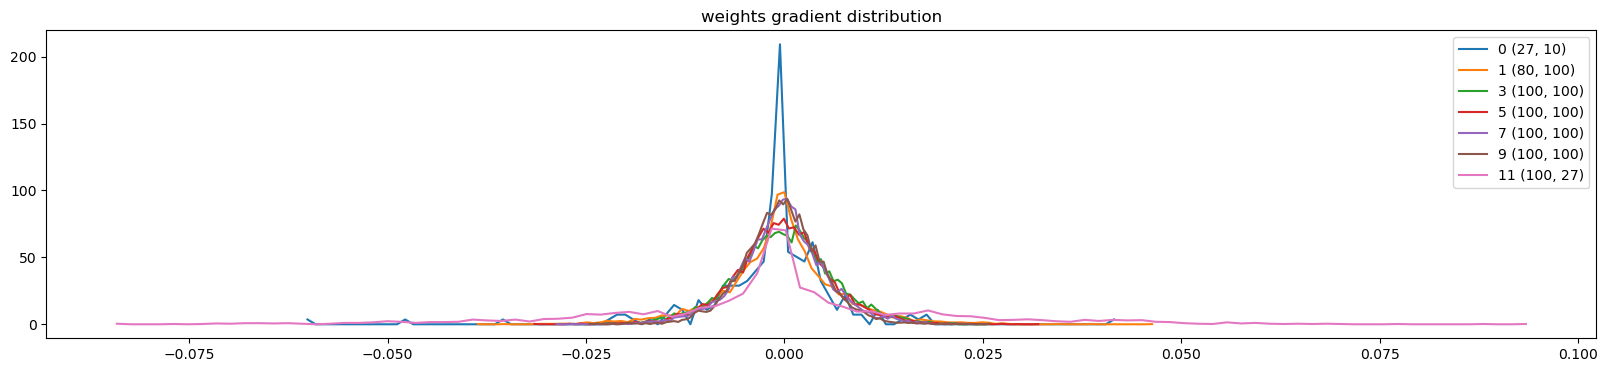

In [77]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2:
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');




plt.show()

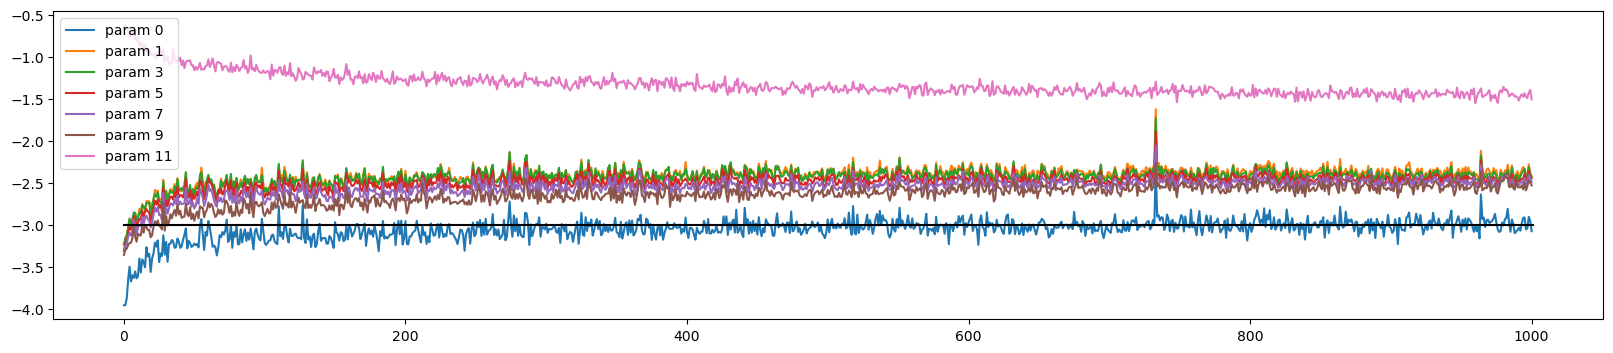

In [78]:
plt.figure(figsize=(20, 4))
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);


plt.show()